# ML Model Benchmark - Emotion Classification
## Comparing 3 Lightweight ML Models

This notebook benchmarks 3 classical ML models:
1. **Logistic Regression** - Baseline model
2. **Naive Bayes (MultinomialNB)** - Perfect for text classification
3. **SVM (LinearSVC)** - Powerful linear classifier

All setup imported from `src/` for clean, reusable code.

In [1]:
# Add src to path
import sys
sys.path.append('../src')

# Import custom modules
from utils.ml_utils import (
    load_data, split_data, vectorize_text,
    evaluate_model, compare_models, save_results
)
from models_ml.models import get_models

# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✓ All modules imported successfully!")

✓ All modules imported successfully!


## 1. Load & Prepare Data

In [2]:
# Load preprocessed data
df = load_data('../data/processed/emotion_dataset_preprocessed.csv')

print(f"\nDataset info:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Classes: {df['emotion'].nunique()}")

# Show distribution
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts())

df.head()

✓ Dataset loaded: (79595, 2)

Dataset info:
  Shape: (79595, 2)
  Columns: ['text', 'emotion']
  Classes: 20

Emotion distribution:
emotion
happiness         7797
disgust           4315
jealousy          4081
surprise          4062
gratitude         4004
relief            3964
guilt             3961
anger             3860
disappointment    3832
embarrassment     3788
anxiety           3776
pride             3772
hope              3770
loneliness        3751
excitement        3643
fear              3574
sadness           3559
confusion         3429
love              3365
frustration       3292
Name: count, dtype: int64


,text,emotion
0,i m so furious with you right now,anger
1,my day is ruined because of this crap,anger
2,i feel like i m about to explode,anger
3,this is the worst day of my life,anger
4,i hate everything about this situation,anger


In [3]:
# Split data
X_train, X_test, y_train, y_test = split_data(df, test_size=0.2, random_state=42)

print(f"\nTrain distribution:")
print(y_train.value_counts())

✓ Train size: 63,676 | Test size: 15,919

Train distribution:
emotion
happiness         6237
disgust           3452
jealousy          3265
surprise          3250
gratitude         3203
relief            3171
guilt             3169
anger             3088
disappointment    3066
embarrassment     3030
anxiety           3021
pride             3018
hope              3016
loneliness        3001
excitement        2914
fear              2859
sadness           2847
confusion         2743
love              2692
frustration       2634
Name: count, dtype: int64


In [4]:
# Vectorize text (TF-IDF)
X_train_tfidf, X_test_tfidf, vectorizer = vectorize_text(
    X_train, X_test, 
    max_features=5000, 
    ngram_range=(1, 2)
)

print(f"\nFeature matrix shape: {X_train_tfidf.shape}")

✓ TF-IDF vectorization complete!
  Features: 5,000
  Sparsity: 99.76%

Feature matrix shape: (63676, 5000)


## 2. Train & Evaluate All Models

In [5]:
# Get all models
models = get_models()

print(f"Models to benchmark:")
for model_name in models.keys():
    print(f"  - {model_name}")

Models to benchmark:
  - Logistic Regression
  - Naive Bayes
  - SVM (LinearSVC)


In [6]:
# Train and evaluate all models
results = {}

for model_name, model in models.items():
    result = evaluate_model(
        model, model_name,
        X_train_tfidf, X_test_tfidf,
        y_train, y_test,
        verbose=True
    )
    results[model_name] = result

print("\n✓ All models trained and evaluated!")


Training Logistic Regression...

Logistic Regression Results:
  Accuracy:  0.8658
  Precision: 0.8659
  Recall:    0.8658
  F1-Score:  0.8656
  Training time: 18.46s
  Prediction time: 0.0138s

Training Naive Bayes...

Naive Bayes Results:
  Accuracy:  0.8382
  Precision: 0.8385
  Recall:    0.8382
  F1-Score:  0.8381
  Training time: 0.30s
  Prediction time: 0.0084s

Training SVM (LinearSVC)...

SVM (LinearSVC) Results:
  Accuracy:  0.8811
  Precision: 0.8810
  Recall:    0.8811
  F1-Score:  0.8808
  Training time: 10.88s
  Prediction time: 0.0087s

✓ All models trained and evaluated!


## 3. Compare Models & Select Best

In [7]:
# Compare all models
comparison_df, best_model_name = compare_models(results)

# Display comparison table
comparison_df.style.background_gradient(cmap='YlGn', subset=['Accuracy', 'F1-Score'])


MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score  Train Time (s)  Pred Time (s)
    SVM (LinearSVC)  0.881085   0.881027 0.881085  0.880836       10.884142       0.008654
Logistic Regression  0.865821   0.865877 0.865821  0.865617       18.464380       0.013804
        Naive Bayes  0.838244   0.838504 0.838244  0.838123        0.296506       0.008433

🏆 Best Model: SVM (LinearSVC) (F1-Score: 0.8808)


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Pred Time (s)
0,SVM (LinearSVC),0.881085,0.881027,0.881085,0.880836,10.884142,0.008654
1,Logistic Regression,0.865821,0.865877,0.865821,0.865617,18.464380,0.013804
2,Naive Bayes,0.838244,0.838504,0.838244,0.838123,0.296506,0.008433


## 4. Visualize Results

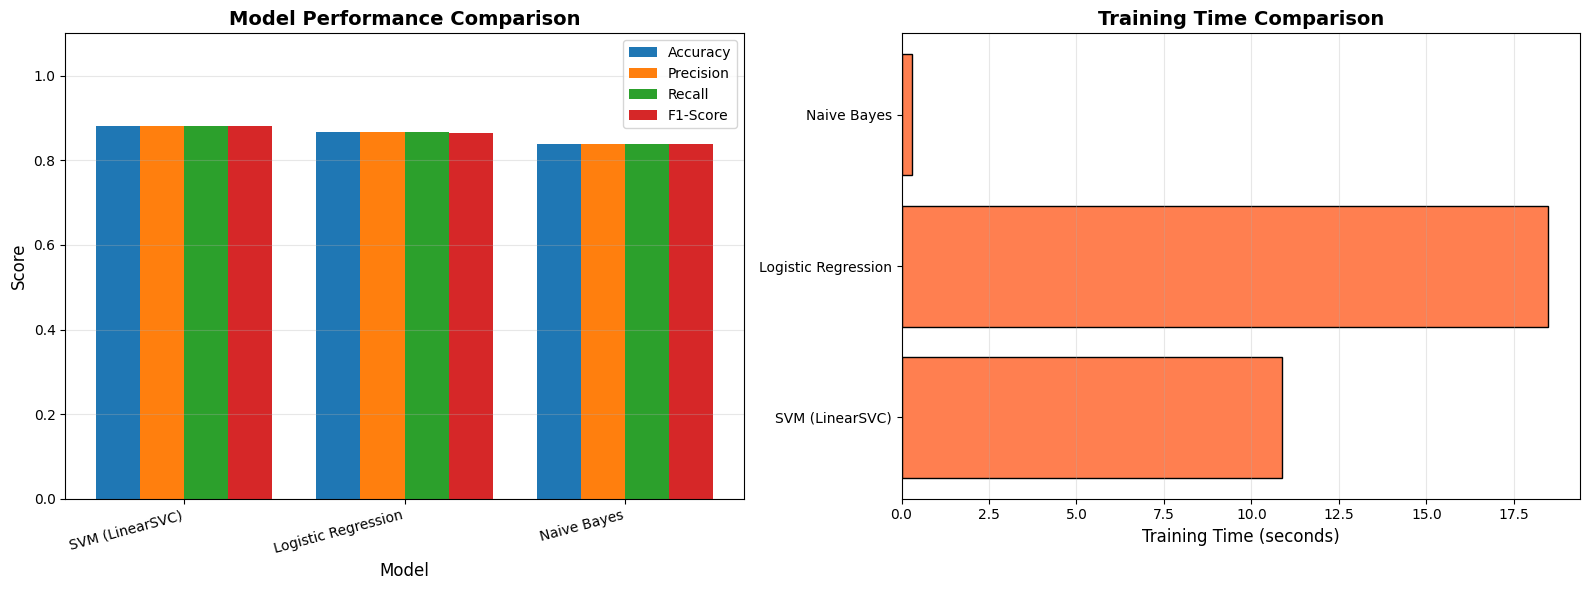

✓ Figure saved to: reports/figures/ml_model_comparison.png


In [8]:
# Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    axes[0].bar(x + i*width, values, width, label=metric)

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Training time
axes[1].barh(comparison_df['Model'], comparison_df['Train Time (s)'], 
             color='coral', edgecolor='black')
axes[1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/ml_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: reports/figures/ml_model_comparison.png")

## 5. Detailed Analysis - Best Model

In [9]:
# Get best model predictions
best_y_pred = results[best_model_name]['y_pred']

print(f"\n{'='*80}")
print(f"Detailed Classification Report - {best_model_name}")
print(f"{'='*80}")
print(classification_report(y_test, best_y_pred, zero_division=0))


Detailed Classification Report - SVM (LinearSVC)
                precision    recall  f1-score   support

         anger       0.73      0.77      0.75       772
       anxiety       0.74      0.78      0.76       755
     confusion       0.90      0.92      0.91       686
disappointment       0.79      0.78      0.78       766
       disgust       0.93      0.90      0.91       863
 embarrassment       0.93      0.93      0.93       758
    excitement       0.96      0.96      0.96       729
          fear       0.83      0.77      0.80       715
   frustration       0.65      0.62      0.64       658
     gratitude       0.89      0.91      0.90       801
         guilt       0.93      0.94      0.94       792
     happiness       0.96      0.97      0.97      1560
          hope       0.93      0.94      0.94       754
      jealousy       0.94      0.95      0.95       816
    loneliness       0.94      0.93      0.93       750
          love       0.95      0.95      0.95       6

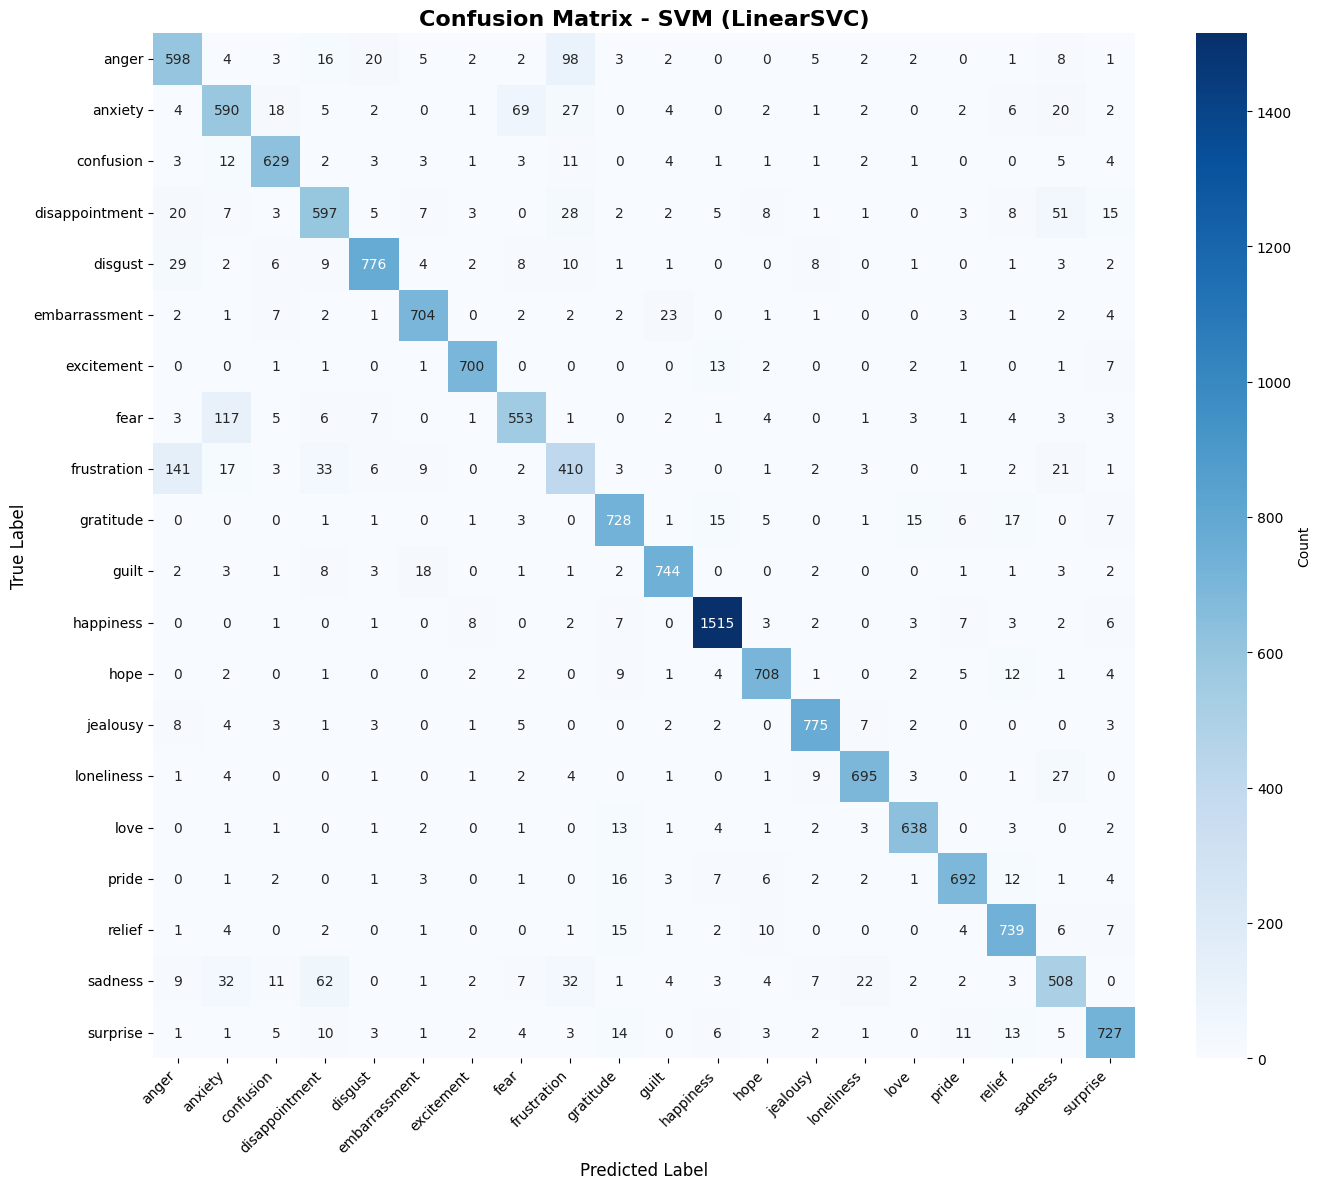

✓ Confusion matrix saved to: reports/figures/confusion_matrix_best_model.png


In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, best_y_pred)
labels = sorted(y_test.unique())

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved to: reports/figures/confusion_matrix_best_model.png")

## 6. Classification Reports - All Models

In [11]:
# Show classification report for all models
for model_name in results.keys():
    print(f"\n{'='*80}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*80}")
    y_pred = results[model_name]['y_pred']
    print(classification_report(y_test, y_pred, zero_division=0))


Classification Report - Logistic Regression
                precision    recall  f1-score   support

         anger       0.72      0.75      0.73       772
       anxiety       0.72      0.76      0.74       755
     confusion       0.87      0.88      0.88       686
disappointment       0.77      0.76      0.77       766
       disgust       0.92      0.89      0.91       863
 embarrassment       0.94      0.91      0.93       758
    excitement       0.95      0.95      0.95       729
          fear       0.83      0.76      0.80       715
   frustration       0.63      0.61      0.62       658
     gratitude       0.88      0.89      0.89       801
         guilt       0.93      0.92      0.93       792
     happiness       0.94      0.96      0.95      1560
          hope       0.91      0.93      0.92       754
      jealousy       0.92      0.94      0.93       816
    loneliness       0.92      0.91      0.92       750
          love       0.93      0.94      0.94       673
  

## 7. Error Analysis

In [12]:
# Analyze errors for best model
errors_df = pd.DataFrame({
    'text': X_test.values,
    'true_emotion': y_test.values,
    'predicted_emotion': best_y_pred
})

errors_df['is_error'] = errors_df['true_emotion'] != errors_df['predicted_emotion']
misclassified = errors_df[errors_df['is_error']]

print(f"\n{'='*80}")
print(f"Error Analysis - {best_model_name}")
print(f"{'='*80}")
print(f"Total test samples: {len(errors_df):,}")
print(f"Correct: {len(errors_df) - len(misclassified):,} ({(len(errors_df)-len(misclassified))/len(errors_df)*100:.2f}%)")
print(f"Errors: {len(misclassified):,} ({len(misclassified)/len(errors_df)*100:.2f}%)")

print(f"\n10 Sample Misclassifications:")
print("="*100)
for i, row in misclassified.head(10).iterrows():
    print(f"\nText: {row['text'][:120]}...")
    print(f"True: {row['true_emotion']:15} | Predicted: {row['predicted_emotion']}")
    print("-"*100)


Error Analysis - SVM (LinearSVC)
Total test samples: 15,919
Correct: 14,026 (88.11%)
Errors: 1,893 (11.89%)

10 Sample Misclassifications:

Text: i wish the concert was on a weekend instead...
True: disappointment  | Predicted: excitement
----------------------------------------------------------------------------------------------------

Text: my day has been pretty crappy so far honestly...
True: sadness         | Predicted: disappointment
----------------------------------------------------------------------------------------------------

Text: losing you feels like losing myself too somehow...
True: sadness         | Predicted: jealousy
----------------------------------------------------------------------------------------------------

Text: this week is already stressing me out badly...
True: sadness         | Predicted: anxiety
----------------------------------------------------------------------------------------------------

Text: my mood is completely ruined thanks for that

## 8. Save Results & Models

In [13]:
# Save comparison and best model
model_path, vectorizer_path = save_results(
    comparison_df, best_model_name, results, vectorizer,
    output_dir='../reports/tables',
    model_dir='../models/ml'
)

print("\n" + "="*100)
print("BENCHMARK COMPLETE!")
print("="*100)
print(f" Best Model: {best_model_name}")
print(f" F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f" Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"  Training Time: {results[best_model_name]['train_time']:.2f}s")
print(f"\n Saved Files:")
print(f"   - Model comparison: reports/tables/ml_model_comparison.csv")
print(f"   - Best model: {model_path}")
print(f"   - Vectorizer: {vectorizer_path}")
print(f"   - Performance plot: reports/figures/ml_model_comparison.png")
print(f"   - Confusion matrix: reports/figures/confusion_matrix_best_model.png")
print("="*100)

✓ Model comparison saved to: ../reports/tables/ml_model_comparison.csv
✓ Best model saved to: ../models/ml/svm_(linearsvc)_model.pkl
✓ Vectorizer saved to: ../models/ml/tfidf_vectorizer.pkl

BENCHMARK COMPLETE!
 Best Model: SVM (LinearSVC)
 F1-Score: 0.8808
 Accuracy: 0.8811
  Training Time: 10.88s

 Saved Files:
   - Model comparison: reports/tables/ml_model_comparison.csv
   - Best model: ../models/ml/svm_(linearsvc)_model.pkl
   - Vectorizer: ../models/ml/tfidf_vectorizer.pkl
   - Performance plot: reports/figures/ml_model_comparison.png
   - Confusion matrix: reports/figures/confusion_matrix_best_model.png


## 9. Test Best Model on Custom Input (Optional)

In [14]:
# Test with custom text
def predict_emotion(text, model, vectorizer):
    """Predict emotion for custom text"""
    text_tfidf = vectorizer.transform([text])
    prediction = model.predict(text_tfidf)[0]
    return prediction

# Get best model
best_model = results[best_model_name]['model']

# Test examples
test_texts = [
    "i am so happy today this is amazing",
    "i am really angry about this situation",
    "this makes me feel so sad and lonely",
    "i am scared and worried about what will happen",
    "i feel surprised by this unexpected news"
]

print("\nTesting Best Model on Custom Inputs:")
print("="*80)
for text in test_texts:
    emotion = predict_emotion(text, best_model, vectorizer)
    print(f"Text: {text}")
    print(f"Predicted Emotion: {emotion}")
    print("-"*80)


Testing Best Model on Custom Inputs:
Text: i am so happy today this is amazing
Predicted Emotion: relief
--------------------------------------------------------------------------------
Text: i am really angry about this situation
Predicted Emotion: anger
--------------------------------------------------------------------------------
Text: this makes me feel so sad and lonely
Predicted Emotion: sadness
--------------------------------------------------------------------------------
Text: i am scared and worried about what will happen
Predicted Emotion: fear
--------------------------------------------------------------------------------
Text: i feel surprised by this unexpected news
Predicted Emotion: surprise
--------------------------------------------------------------------------------
